# 07 - K-Means (aprendizado nao supervisionado)

## Conceito
K-Means agrupa amostras em K clusters minimizando a soma das distancias
quadraticas de cada ponto ao centroide do seu cluster.

## Algoritmo
1. Escolher K centroides iniciais (aleatorio ou k-means++)
2. Atribuir cada ponto ao centroide mais proximo
3. Recalcular centroides como media dos pontos do cluster
4. Repetir 2 e 3 ate convergir

## Desafios
- Escolher K: metodo do cotovelo (elbow) ou silhouette
- Inicializacao: k-means++ melhora convergencia
- Escala: precisa normalizar
- Forma dos clusters: assume clusters esfericos e de tamanho similar

## Metricas
- Inertia: soma das distancias quadraticas intra-cluster (menor melhor)
- Silhouette: quao bem cada ponto se encaixa no seu cluster (-1 a 1)
- Davies-Bouldin: razao entre dispersao intra e separacao entre clusters

## Quando usar
- Segmentacao de clientes
- Compressao de imagens
- Deteccao de padroes sem rotulos
- Pre-processamento (features discretizadas)

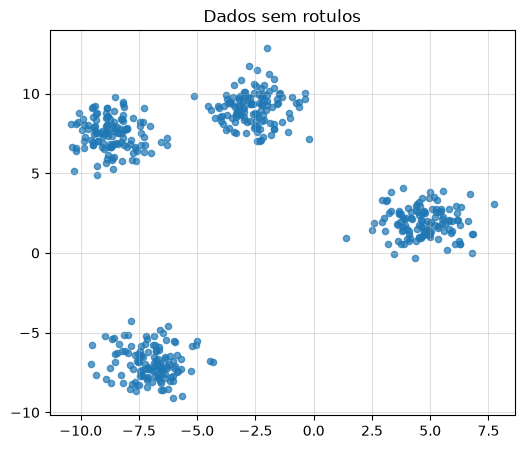

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Gerando dados sinteticos com 4 clusters bem separados
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42) # type: ignore

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7)
plt.title("Dados sem rotulos")
plt.grid(True, alpha=0.4)
plt.show()

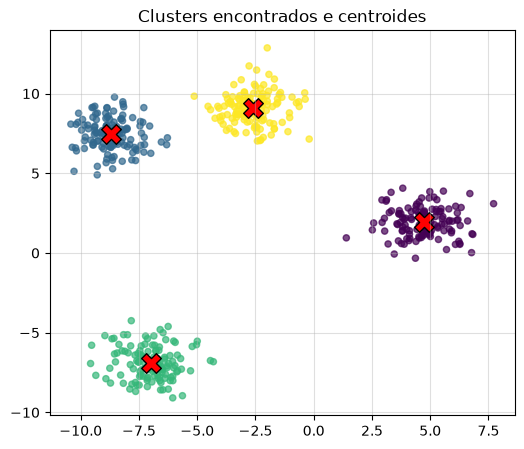

Inertia: 948.89
Silhouette: 0.791


In [2]:
# Treinando K-Means com K=4
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
rotulos = kmeans.fit_predict(X)
centroides = kmeans.cluster_centers_

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=rotulos, cmap="viridis", s=20, alpha=0.7)
plt.scatter(centroides[:, 0], centroides[:, 1], c="red", s=200, marker="X", edgecolor="black")
plt.title("Clusters encontrados e centroides")
plt.grid(True, alpha=0.4)
plt.show()

print("Inertia:", round(kmeans.inertia_, 2))
print("Silhouette:", round(silhouette_score(X, rotulos), 3))

## Escolhendo K: metodo do cotovelo

Plotamos inertia para varios K. O "cotovelo" (ponto onde a queda desacelera)
sugere um bom K.

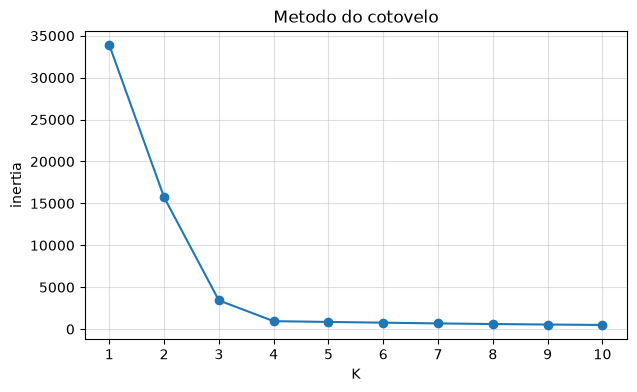

In [3]:
ks = range(1, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("inertia")
plt.title("Metodo do cotovelo")
plt.xticks(list(ks))
plt.grid(True, alpha=0.4)
plt.show()

## Escolhendo K: silhouette

O silhouette varia de -1 a 1. Valores proximos de 1 indicam clusters bem
separados. Calculamos para varios K e escolhemos o de maior score.

Melhor K (silhouette): 4


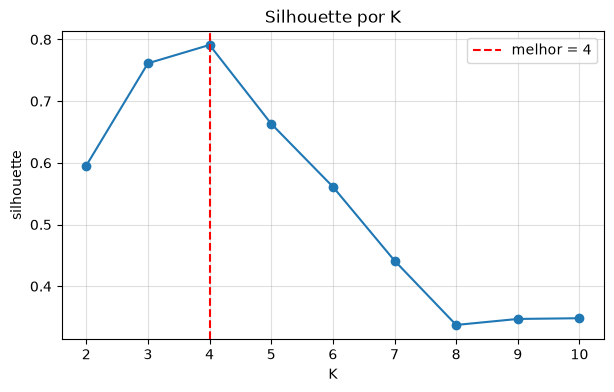

In [4]:
ks = range(2, 11)
scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    rot = km.fit_predict(X)
    scores.append(silhouette_score(X, rot))

melhor_k = list(ks)[int(np.argmax(scores))]
print("Melhor K (silhouette):", melhor_k)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), scores, marker="o")
plt.axvline(melhor_k, color="red", linestyle="--", label=f"melhor = {melhor_k}")
plt.xlabel("K")
plt.ylabel("silhouette")
plt.title("Silhouette por K")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## K-Means no dataset iris

Sem usar as classes, agrupamos e depois comparamos com os rotulos reais.

In [5]:
iris = load_iris()
X_iris = iris.data #type: ignore
y_iris = iris.target #type: ignore

# Normalizando
X_iris_s = StandardScaler().fit_transform(X_iris)

km = KMeans(n_clusters=3, n_init=10, random_state=42)
rotulos = km.fit_predict(X_iris_s)

print("Silhouette:", round(silhouette_score(X_iris_s, rotulos), 3))

# Comparando com as classes reais via tabela de contingencia
import pandas as pd
tabela = pd.crosstab(y_iris, rotulos, rownames=["classe real"], colnames=["cluster"])
print("\nTabela de contingencia:")
print(tabela)

Silhouette: 0.46

Tabela de contingencia:
cluster       0   1   2
classe real            
0             0  50   0
1            39   0  11
2            14   0  36


## Exercicios

1. Rode K-Means com K=4 no dataset iris e compare com K=3.
2. Normalize vs nao normalize antes do K-Means. Qual a diferenca?
3. Aplique K-Means em uma imagem colorida reduzindo as cores para 8 clusters.
4. Compare K-Means e AgglomerativeClustering no mesmo dataset.